Welcome to my Quant Interview Project! 

In this project we are going to import some historical datas about some thousands cryptos (data downloaded on coinbase.com) and analyse them to calculate and show key metrics, such as daily returns, volatility rates and value over selected timespans.

First, I'll import the datas, grouped in a folder, separatedly and I'll merge them all in an unique pandas dataframe

I've preliminarly chose the main columns I'll use for my correlations analysis, which are :

'time' = self-explaining 

'AdrBalUSDXCnt' = count the number of unique addresses whose portfolio value in dollars is bigger than X

'IssContNtv' = the number of native tokens issued on a certain date

'ReferenceRate' = the price of the crypto, averaged on the various exchanges. It represents the 'true value' and it's prefered over the usual price metrics as it's considered to be more reliable and stable for these kind of analysis

'TxCnt' = the count of total transactions

'Cryptocurrency' = the name of the crypto

In [1]:
import os
import pandas as pd
import matplotlib 
import numpy as np

# List of all possible columns (from both groups)
all_columns = ['time', 'AdrBalUSD1Cnt', 'AdrBalUSD100Cnt', 'AdrBalUSD10KCnt', 
               'AdrBalUSD1MCnt', 'IssContNtv', 'ReferenceRate', 'TxCnt', 'Cryptocurrency']

# List of CSV files in the directory
directory_file = '/Users/baudotedua/Dropbox/Mac/Desktop/PYTHON/QUANT/QuantInterviewProject/csv/'

csv_files = [f for f in os.listdir(directory_file) if f.endswith('.csv')]

df_list = []

for file in csv_files:
    file_path = os.path.join(directory_file, file)
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Extract the cryptocurrency name from the filename
    crypto_name = file.split('.')[0]
    df['Cryptocurrency'] = crypto_name
    
    # Picking only the 'all_columns', filling missing columns with NaN
    df = df.reindex(columns=all_columns)
    
    # Append the dataframe to the list if it contains more than 31*6 values (6 months)
    if df.shape[0] > 31*6:
        df_list.append(df)

# Combine all dataframes
df_final = pd.concat(df_list, ignore_index=True)

# Now we have a single dataframe 'df_final' including only the chosen columns


/var/folders/l4/ybqxqy391fx0g8rhn62_7n1h0000gn/T/ipykernel_2862/3089142505.py:21: DtypeWarning: Columns (147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Now I'll change the 'time' column, using the pandas.to_datetime function, to allow better operations on it.

In [2]:

df_final['time'] = pd.to_datetime(df_final['time'])


Let's now define the functions we'll be using throughout the analysis

In [3]:
def gettimedelta(df,start,end):
     
    """
    Select only the date rows included in the timespan

    Parameters:
        df (pandas.DataFrame): DataFrame containing the values.
        start (string) : starting date
        end (string) : ending date

    Returns:
        filtered_df (pandas.DataFrame): A dataframe containing values for the selected rows only
    """
    
    starttime=pd.to_datetime(start)
    starttime=starttime 
    endtime=pd.to_datetime(end)
    filtered_df = df[(df['time'] >= starttime) & (df['time'] <= endtime)]
    return filtered_df


In [4]:
def getreturn(cryptos,df_new,start,end):
    """
    Calculate, for the given cryptocurrencies, the return on the selected timespan

    Parameters:
        cryptos (list of string): the list of selected cryptos' tickers 
        df_new (pandas.DataFrame) : DataFrame containing the values.
        start (string) : starting date
        end (string) : ending date

    Returns:
        returns (float): the value of return on the cryptos' prices in the selected timespan
    """
    df_new=gettimedelta(df_new,start,end)
    
    df_new=df_new[df_new['Cryptocurrency'].isin(cryptos)]
    
    df_new=df_new.reset_index(drop=True)
    returns=[]
    for crypto in cryptos:
        #more versatile
        mintime=df_new[df_new['Cryptocurrency']==crypto].time.min()
        valuex=df_new[df_new['time']==mintime].ReferenceRate.iloc[0]       
        maxtime=df_new[df_new['Cryptocurrency']==crypto].time.max()
        valuey=df_new[df_new['time']==maxtime].ReferenceRate.iloc[0]

        value=(valuey-valuex)/valuex

        returns.append(value)
    return returns



In [ ]:
'''
def getreturn1(cryptos,df_new,start,end):
    df_new=gettimedelta(df_new,start,end)
    
    df_new=df_new[df_new['Cryptocurrency'].isin(cryptos)]

    df_pivot = df_new.pivot(index='time', columns='Cryptocurrency', values='value')
    full_date_range = pd.date_range(start=df['date'].min(), end=df['date'].max())
    df_new = df_pivot.reindex(full_date_range)


    df_new=df_new.reset_index(drop=True)
    returns=[]
    for crypto in cryptos:
        valuex=df_new.loc[(df_new['Cryptocurrency']==crypto) & (df_new['time']==start)].ReferenceRate.iloc[0]
        
        valuey=df_new.loc[(df_new['Cryptocurrency']==crypto) & (df_new['time']==end)].ReferenceRate.iloc[0]
        
        value=(valuey-valuex)/valuex

        returns.append(value)
    return returns
    '''

In [5]:
def getdailyreturns(cryptos,df_new,feature1,variation):
    """  
    Calculate, for the given cryptocurrencies, the daily variation of the selected feature over the selected timespan, and add the
    values as a column.

    Parameters:
        cryptos (list of string): the list of selected cryptos' tickers 
        df_new (pandas.DataFrame) : DataFrame containing the values.
        feature1 (string) : the name of the feature (the column) we'd like to calculate the daily variation 
        variation (string) : the name of the newly added column

    Returns:
        df_new (pandas.DataFrame): the starting dataframe with a new column for the daily variations.
    """
    
    
    df_new=df_new[df_new['Cryptocurrency'].isin(cryptos)]
    df_new=df_new.reset_index(drop=True)

    df_new.loc[:,variation] = 0.0

    
    for i in range(df_new.shape[0]):
        if i == 0:
            df_new.loc[i,variation] = 0
        elif (df_new['Cryptocurrency'].iloc[i] == df_new['Cryptocurrency'].iloc[i-1]) and (df_new[feature1].iloc[i-1] != 0) :
            df_new.loc[i, variation] = ((df_new[feature1].iloc[i] - df_new[feature1].iloc[i-1]) / df_new[feature1].iloc[i-1]) * 100
        else:
            df_new.loc[i, variation] = 0

    return df_new

In [6]:
import matplotlib.pyplot as plt 
import itertools
import matplotlib.dates as mdates
def plotthedatas(df,feature,startdate,enddate,cryptos):
    """  
    Plot, for the given cryptos, the selected features (columns) over a given timespan

    Parameters:
        
        df (pandas.DataFrame) : DataFrame containing the values.
        feature (string) : the name of the feature (the column) we'd like to plot
        startdate (string) : the starting date
        enddate (string) : the ending date
        cryptos (list of string): the list of selected cryptos' tickers 

    Returns:
        
    """
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    color_cycle = itertools.cycle(colors)  # Create a cycle of colors
    for crypto in cryptos:

        #Iterate over the selected cryptos
        var = df.loc[df['Cryptocurrency'] == crypto]

        color = next(color_cycle)
        plt.plot(var['time'], var[feature], color=color, label=crypto, linewidth=0.6,alpha=0.8)
        plt.title('{} from {} to {} days'.format(feature,startdate,enddate))
        plt.xlabel('Date')

        #Adding some conditions for better readibility
        if var.shape[0]<32:
            plt.gca().xaxis.set_major_locator(mdates.DayLocator())
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
            plt.gcf().autofmt_xdate(rotation=45) 
        elif var.shape[0]<367:
            plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be at each month
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format to show month and year
            plt.gcf().autofmt_xdate(rotation=45)
        else :
            plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    
        plt.ylabel('{} (%)'.format(feature))
        plt.legend()
        plt.grid() 
    plt.show()
    return

In [7]:
def getvolatility(cryptos,df_new,feature,variation):
    """ 
    Calculate the volatily of the given feature (column) over a time-range of 15 days

    Parameters:
        
        cryptos (list of string): the list of selected cryptos' tickers
        df_new (pandas.DataFrame) : DataFrame containing the values.
        feature (string) : the name of the feature (the column) we'd like to plot
        variation (string) : the name of the newly created column
         

    Returns:

        df_new (pandas.DataFrame) : the given dataframe with the new column of the feature's volatility added to it  
    """

    #df_new=gettimedelta(df_new,start,end)
    df_new=df_new[df_new['Cryptocurrency'].isin(cryptos)]
    
    df_new=df_new.reset_index(drop=True)
    #df_new=df_new[['time','Cryptocurrency','DailyRet','ReferenceRate']]
    df_new.loc[:,variation] = 0.0
    grouped = df_new.groupby('Cryptocurrency')

    for crypto,group in grouped:
        for i in range(len(group)):
            #len group is = days selected
            if i< 15:
                df_new.loc[group.index[i],variation]=0
            else:
                values=group[feature].iloc[i-15:i+1]
                df_new.loc[group.index[i],variation]=values.std().round(3)

    df_new= df_new.groupby('Cryptocurrency').apply(lambda x: x.iloc[15:])
  
    return df_new





I'll sort the crypto list by 'importance', considered to be the average price

In [8]:

crypto_group=df_final.groupby('Cryptocurrency').ReferenceRate.mean()
print(crypto_group)
crypto_group=crypto_group.sort_values(axis='index', ascending=False)
print(crypto_group)

Cryptocurrency
1cat         0.004919
1inch        1.390159
aave       152.003615
abbc         0.133150
abt          0.396632
              ...    
zil_eth           NaN
zkf          0.004741
zks          0.482734
zrx          0.519623
ztx_ztx      0.016039
Name: ReferenceRate, Length: 1034, dtype: float64
Cryptocurrency
hbtc         2.334047e+07
tbtc         3.970338e+04
renbtc       3.306171e+04
wbtc         3.024466e+04
yfi          1.665298e+04
                 ...     
usdt_eth              NaN
usdt_omni             NaN
usdt_trx              NaN
vet_eth               NaN
zil_eth               NaN
Name: ReferenceRate, Length: 1034, dtype: float64


Now I'll create a program that asks the user which cryptocurrencies and timespan he'd like to calculate the daily returns and the volatility rate on.

Then, it plots price , daily return , and volatily over the selected timespan

You selected the following cryptos: ['btc', 'eth', 'doge']


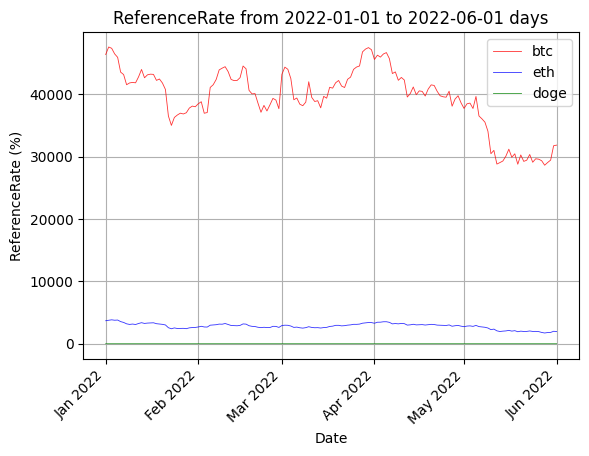

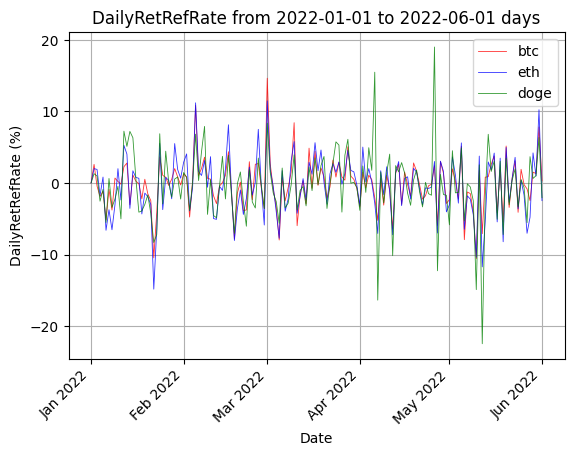

/var/folders/l4/ybqxqy391fx0g8rhn62_7n1h0000gn/T/ipykernel_2862/242457297.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_new= df_new.groupby('Cryptocurrency').apply(lambda x: x.iloc[15:])


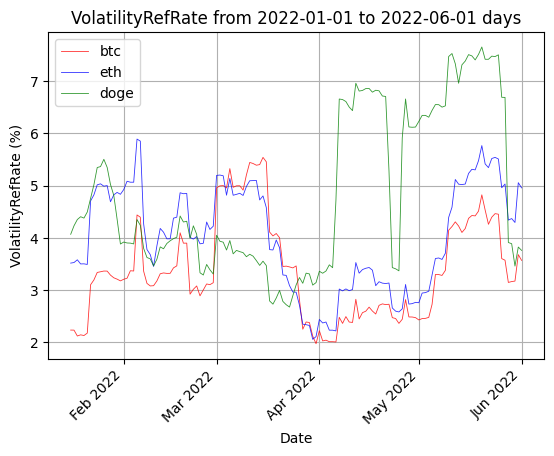

In [9]:
cryptos_input=input("Please enter the cryptocurrencies you want to track, separated by commas:\nIf you want to see all the available cryptos type 'show' ")

while cryptos_input=='show':
    cryptoset=crypto_group.index.tolist()
    print(cryptoset)
    cryptos_input = input("Please enter the cryptocurrencies you want to track, separated by commas:\nIf you want to see all the available cryptos type 'show' ")


cryptos_list = [crypto.strip() for crypto in cryptos_input.split(',')]
print('You selected the following cryptos:',cryptos_list)

startdate=input('Choose the start date (e.g. 2024-01-01)')
enddate=input('Choose the end date (e.g. 2024-01-01)')
starting=pd.to_datetime(startdate)


df_filtered=gettimedelta(df_final,startdate,enddate)
plotthedatas(df_filtered,'ReferenceRate',startdate,enddate,cryptos_list) #Plot the price over time

df_filtered=getdailyreturns(cryptos_list,df_filtered,'ReferenceRate','DailyRetRefRate')
plotthedatas(df_filtered,'DailyRetRefRate',startdate,enddate,cryptos_list) #Plot the daily returns over time

starting = starting  - pd.Timedelta(days=15) #To calculate volatily on the first 15 values we have to fetch the previous 15 values too

df_filtered=getvolatility(cryptos_list,df_filtered,'DailyRetRefRate','VolatilityRefRate')
plotthedatas(df_filtered,'VolatilityRefRate',startdate,enddate,cryptos_list) #Plot volatility rate over time



    

Let's now plot the returns distribution

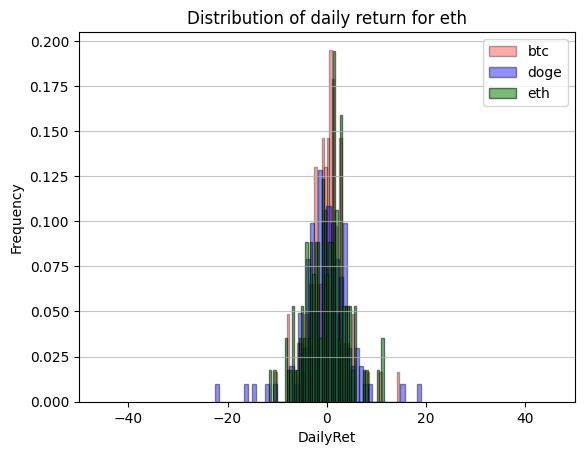

In [10]:
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
color_cycle = itertools.cycle(colors)  
i=1/len(cryptos_list)
for cryptos in df_filtered.Cryptocurrency.unique():
    
    data=df_filtered.loc[df_filtered['Cryptocurrency']==cryptos].DailyRetRefRate.iloc[15:]
    color=next(color_cycle)
    plt.hist(data,bins=50,color=color,density=True,alpha=i,edgecolor='black',label=cryptos)
    plt.title('Distribution of daily return for {}'.format(cryptos))
    plt.xlabel('DailyRet')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y',alpha=0.75)
    i=i+0.1
    plt.xlim(-50, 50)
    
plt.show()

CRYPTOS CORRELATIONS

Among the most relevant indexes in financial analysis we can find Alpha and Beta, two values that can give us important informations on a portfolio/stock behaviour over time, compared to a chosen benchmark.

Alpha = calculated as Ri - (Rf + beta*(Rm - Rf))

where :

Ri = the return on the investment 

Rf = the risk-free rate on the selected timespan, usually it's considered to be the US Treasury Bonds return rate

Rm = the return of the 'market', the selected benchmark

-> *Alpha* tells us whether our portfolio/stock would have beaten the market given its correlation to it and the market-overall conditions

Beta = calculated as Cov(Rm,Ri)/Var(Rm) 

-> *Beta* tells us how the market fluctuations directly influence our portfolio/stock variations.

A Beta value of 1 says that our portfolio variations are directly related to the market variations, whereas a value of -1 says about its inverse relation. 

The program allows the user to choose the cryptos compounding the 'market' portfolio, allowing him to select a given topcryptos list.

It then allows him to choose the personal portfolio and the timespan.

[]

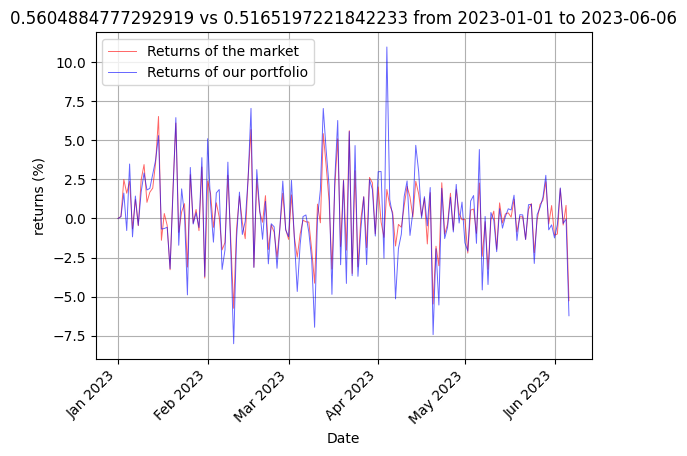

In [11]:

topcryptos=["btc", "eth", "usdt", "bnb", "xrp", 
    "usdc", "sol", "ada", "doge"]
main_cryptos=input('Select the group of cryptos you want to set as benchmark (e.g. btc,eth...), press \'top\' to put the top 10 ')
if main_cryptos=='top':
    main_cryptos=topcryptos
else :
    main_cryptos=[crypto.strip() for crypto in main_cryptos.split(',')]
my_crypto=input('Select your list of cryptos (e.g. btc,eth...)')
my_crypto = [crypto.strip() for crypto in my_crypto.split(',')]

start=input('Choose the start date (e.g. 2024-01-01)')
end=input('Choose the end date (e.g. 2024-01-01)')

df_alphabeta=gettimedelta(df_final,start,end)

Rfvect={'2024':4,
    '2023':0.04,
    '2022':0.03,
    '2021':0.014,
    '2020':0.012,
    '2019':0.025,
    '2018':0.027,
    '2017':0.025,
    '2016':0.02,
    '2015':0.02,
    '2014':0.024}


Rf=Rfvect[start[0:4]] #Select the corresponding Risk-Free rate 

Rivect=getreturn(my_crypto,df_alphabeta,start,end) #Calculate the return of our portfolio in the given timespan
Ri=sum(Rivect)/len(Rivect)


Rmvect=getreturn(main_cryptos,df_alphabeta,start,end) #Calculate the return of the benchmark in the given timespan
Rm=sum(Rmvect)/len(Rmvect)

Rmdaily=getdailyreturns(main_cryptos,df_alphabeta,'ReferenceRate','DailyRet').groupby('time').DailyRet.mean()
Ridaily=getdailyreturns(my_crypto,df_alphabeta,'ReferenceRate','DailyRet').groupby('time').DailyRet.mean()

covariance_rm_ri=np.cov(Rmdaily,Ridaily)[0,1]
variance_rm=np.var(Rmdaily)

x_axis =pd.date_range(start=start, end=end).tolist()
y1_axis=Rmdaily
y2_axis=Ridaily
plt.plot(x_axis, y1_axis, color='red', label='Returns of the market',alpha=0.6,linewidth=0.7)
plt.plot(x_axis, y2_axis, color='blue', label='Returns of our portfolio',alpha=0.6,linewidth=0.7)
plt.title('{} vs {} from {} to {}'.format(Rm,Ri,start,end))
plt.xlabel('Date')
if len(x_axis)<=31:
    plt.gca().xaxis.set_major_locator(mdates.DayLocator())  
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
    plt.gcf().autofmt_xdate(rotation=45)
elif len(x_axis)<367:
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
    plt.gcf().autofmt_xdate(rotation=45)
else :
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate(rotation=45)
plt.ylabel('returns (%)')
plt.legend()
plt.grid()
plt.plot()

In [12]:
def lincorr(x,y):
    """"
    Calculate the linear correlation matrix of the given arrays

    Parameters:
        x (list of int): list containing the first array of values
        y (list of int): list containing the second array of values

    Returns:
        rho (matrix of float) : matrix containing values of linear correlations between arrays   
    """
    plt.scatter(x, y, color='blue', marker='o')
    plt.title('Scatter Plot of Two Vectors')
    plt.xlabel('X values')
    plt.ylabel('Y values')
    plt.grid()
    plt.show()
    rho=np.corrcoef(x,y)[1,0]
    return rho

Let's calculate and show alpha, beta and rho values

Beta value is  1.242460830645816

Alpha value is  -17.016682419688898 %


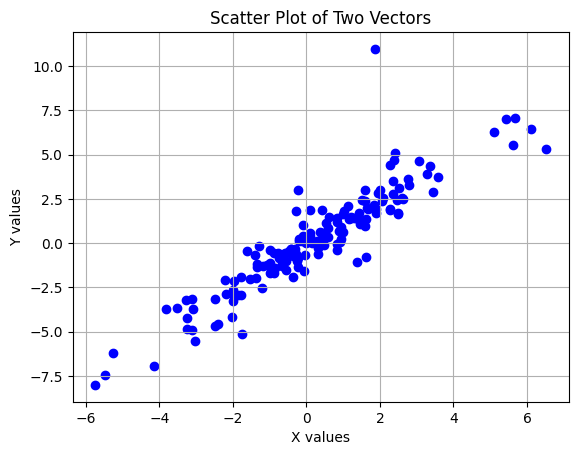


Linear correlation index is  0.9164776779073278


In [13]:
beta=covariance_rm_ri/variance_rm
print('Beta value is ',beta)
alpha = (Ri - (Rf + beta*(Rm-Rf)))*100
print('\nAlpha value is ',alpha,'%')
rho=lincorr(Rmdaily,Ridaily)
print('\nLinear correlation index is ',rho)


Let's now see if the releasing of new liquidity in the market has any effect on inflative behaviours

[]

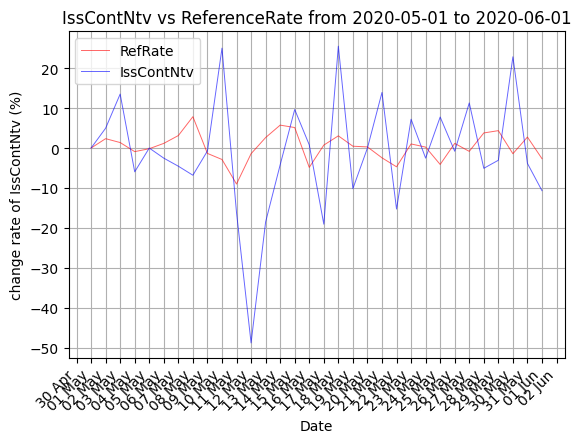

In [14]:

start='2020-05-01' 
end='2020-06-01'
df_filtered_2=gettimedelta(df_final,start,end)
crypto=['btc']
df_filtered_2=df_filtered_2[df_filtered_2['Cryptocurrency'].isin(crypto)]
feature='IssContNtv'

df_filtered_2=getdailyreturns(crypto,df_filtered_2,'ReferenceRate','DailyRet')
df_filtered_2=getdailyreturns(crypto,df_filtered_2,'IssContNtv','DailyChangeIssContNtv')
x_axis=df_filtered_2.time.tolist()
y1_axis=df_filtered_2.DailyRet.tolist()
y2_axis=df_filtered_2.DailyChangeIssContNtv.tolist()
plt.plot(x_axis, y1_axis, color='red', label='RefRate',alpha=0.6,linewidth=0.7)
plt.plot(x_axis, y2_axis, color='blue', label=feature,alpha=0.6,linewidth=0.7)
plt.title('{} vs {} from {} to {}'.format(feature,'ReferenceRate',start,end))
plt.xlabel('Date')
plt.gca().xaxis.set_major_locator(mdates.DayLocator())  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b')) 
plt.gcf().autofmt_xdate(rotation=45)
plt.ylabel('change rate of {} (%)'.format(feature))
plt.legend()
plt.grid()
plt.plot()


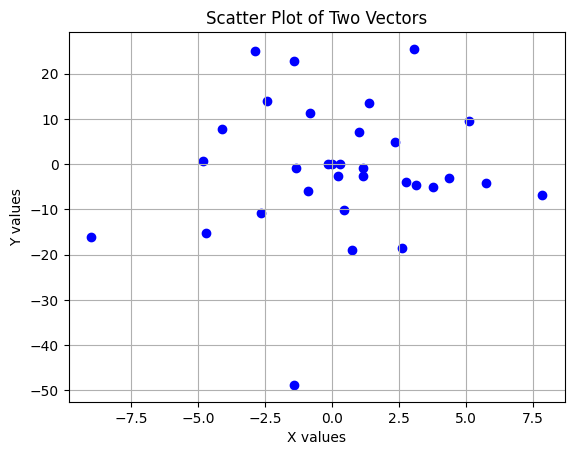

Linear correlation index is  0.07028462395668134


In [15]:
rho=lincorr(y1_axis,y2_axis)
print('Linear correlation index is ',rho)

Let's now see how the selected crypto has centralized or decentralized its value over time

[]

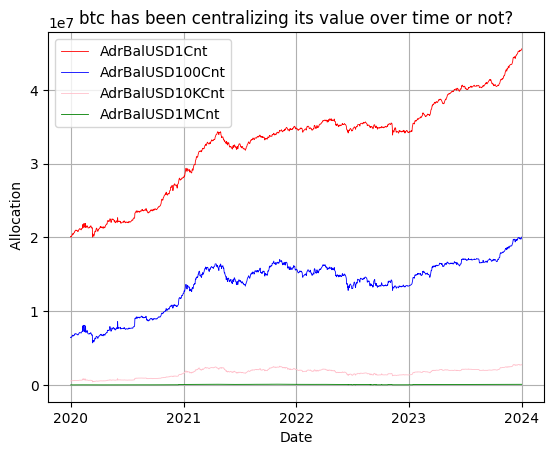

In [16]:

crypto='btc'
start='2020-01-01'
end='2024-01-01'
df_filtered_3=gettimedelta(df_final,start,end)
df_filtered_3=df_filtered_3.loc[df_filtered_3['Cryptocurrency']==crypto]
x_axis=df_filtered_3.time.tolist()
y1_axis=df_filtered_3.AdrBalUSD1Cnt.tolist()
y2_axis=df_filtered_3.AdrBalUSD100Cnt.tolist()
y3_axis=df_filtered_3.AdrBalUSD10KCnt.tolist()
y4_axis=df_filtered_3.AdrBalUSD1MCnt.tolist()
plt.plot(x_axis,y1_axis,color='red',label='AdrBalUSD1Cnt',linewidth=0.6)
plt.plot(x_axis,y2_axis,color='blue',label='AdrBalUSD100Cnt',linewidth=0.6)
plt.plot(x_axis,y3_axis,color='pink',label='AdrBalUSD10KCnt',linewidth=0.6)
plt.plot(x_axis,y4_axis,color='green',label='AdrBalUSD1MCnt',linewidth=0.6)
plt.title('{} has been centralizing its value over time or not?'.format(crypto))
plt.xlabel('Date')
if df_filtered_3.shape[0]<365*2:
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be at each month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format to show month and year
else :
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.ylabel(' Allocation')
plt.legend()
plt.grid()
plt.plot()


Let's better see the distribution of the owners of big quantities

[]

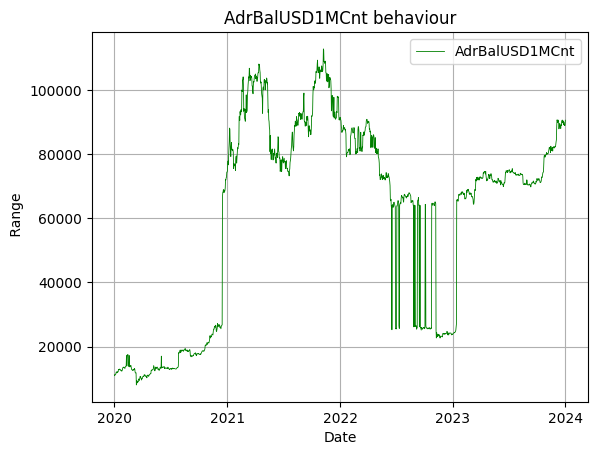

In [17]:

plt.plot(x_axis,y4_axis,color='green',label='AdrBalUSD1MCnt',linewidth=0.6)
plt.title('{} behaviour'.format('AdrBalUSD1MCnt'))
plt.xlabel('Date')
if df_filtered_3.shape[0]<365*2:
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be at each month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format to show month and year
else :
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.ylabel(' Range')
plt.legend()
plt.grid()
plt.plot()

Let's now see if there are any correlations between the volume of trading and the price of the selected crypto

[]

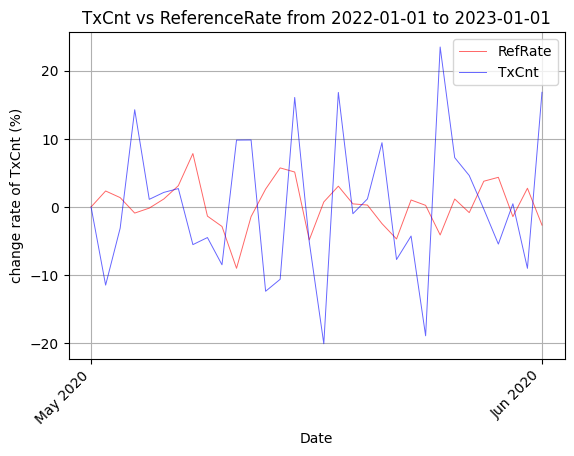

In [18]:

start='2022-01-01' 
end='2023-01-01'
crypto=['btc']
feature='TxCnt'

df_filtered_2=getdailyreturns(crypto,df_filtered_2,'ReferenceRate','DailyRet')
df_filtered_2=getdailyreturns(crypto,df_filtered_2,'TxCnt','DailyChangeTxCnt')
x_axis=df_filtered_2.time.tolist()
y1_axis=df_filtered_2.DailyRet.tolist()
y2_axis=df_filtered_2.DailyChangeTxCnt.tolist()
plt.plot(x_axis, y1_axis, color='red', label='RefRate',alpha=0.6,linewidth=0.7)
plt.plot(x_axis, y2_axis, color='blue', label=feature,alpha=0.6,linewidth=0.7)
plt.title('{} vs {} from {} to {}'.format(feature,'ReferenceRate',start,end))
plt.xlabel('Date')
if df_filtered_2.shape[0]>367:
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # Set major ticks to be at each year
else:
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to be at each month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format to show month and year
    plt.gcf().autofmt_xdate(rotation=45)
plt.ylabel('change rate of {} (%)'.format(feature))
plt.legend()
plt.grid()
plt.plot()


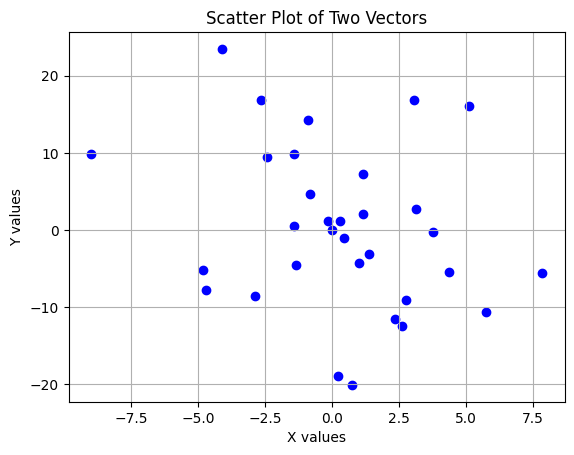

Linear correlation index is  -0.2514004358606072


In [19]:
rho=lincorr(y1_axis,y2_axis)
print('Linear correlation index is ',rho)

QUALITATIVE ANALYSIS

COVID-19 has been a disruptive event for the financial and economic world. Countries' GDP faltered, businesses closed, and fear spread wide in the markets.

It's well known that, when uncertainty arises, investors rush to sell riskier assets (like equities) and shift toward safer investments, such as government bonds, gold, and U.S. dollars. 

This is exactly what happened, but it's interesting to see how crytpocurrencies behaved during these rough months; did people consider them risky and dangerous, or did they spoiled the situation to grow and expand their market shares?

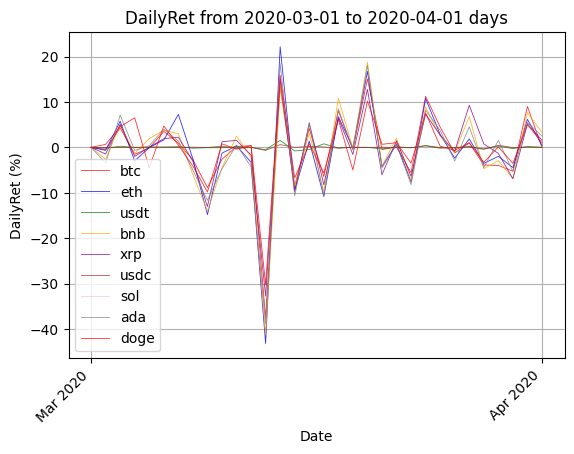

In [20]:
start='2020-03-01' 

end='2020-04-01'
df=gettimedelta(df_final,start,end)
df=getdailyreturns(topcryptos,df,'ReferenceRate','DailyRet')
plotthedatas(df,'DailyRet',start,end,topcryptos)

Let's zoom on Bitcoin's behaviour

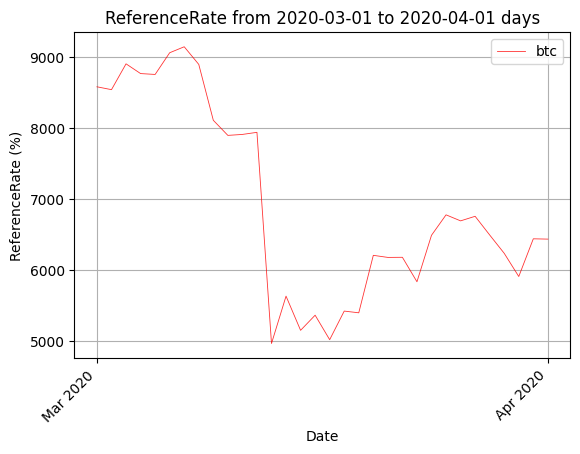

In [21]:
end='2020-04-01'
df_btc_covid=gettimedelta(df_final,start,end)

plotthedatas(df_btc_covid,'ReferenceRate',start,end,['btc'])

As we can see, the value of the main cryptos during the first months of lockdown decreased a lot, but right after the first shock, it started to soar, slowly but steadily, until it touched its all-time high.

This is because, as the whole world shifted to internet, many people started using those cryptocurrencies as proper exchange values, and, considering the global political situation, a decentralized currency looked to many as more secure and less affected by monetary restrictions.

As always, the market too played its role and, once the market value started rising, lucrative behaviours spurred the price even further.

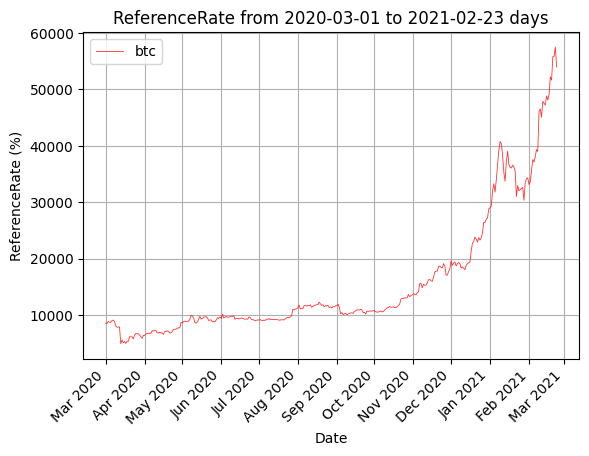

In [22]:
end='2021-02-23'
df_btc_covid=gettimedelta(df_final,start,end)

plotthedatas(df_btc_covid,'ReferenceRate',start,end,['btc'])

In May 2022, the collapse LUNA sent shockwaves through the crypto market. What happened was that the LUNA crypto ecosystem was strictly connected to the UST stable coin, a coin that was pegged to the dollar 1:1.

UST started losing its peg, causing an increasing issuing of LUNA tokens, which by consequence started a spyral that ended in its crash.

This event led to widespread panic and a massive selloff, as investors lost confidence in stablecoins and related projects, fueling the vision of those considering cryptos just speculative instruments and risky assets.

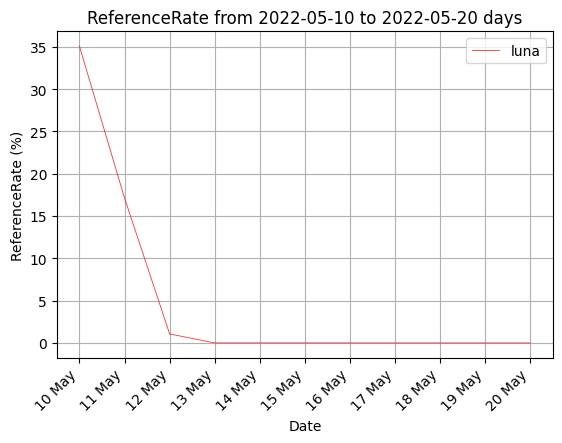

In [23]:
crypto=['luna'] 
feature='ReferenceRate'
start='2022-05-10' 
end='2022-05-20'
df_luna=gettimedelta(df_final,start,end)
plotthedatas(df_luna,feature,start,end,crypto)


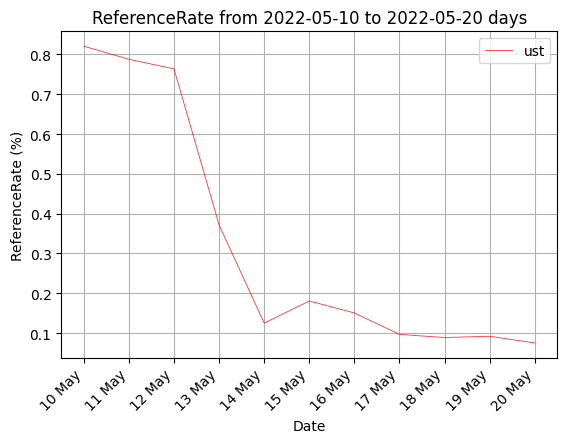

In [24]:
crypto=['ust'] 
feature='ReferenceRate'
start='2022-05-10' 
end='2022-05-20'
df_luna=gettimedelta(df_final,start,end)
plotthedatas(df_luna,feature,start,end,crypto)


Let's see if this had effects on other cryptocurrencies 

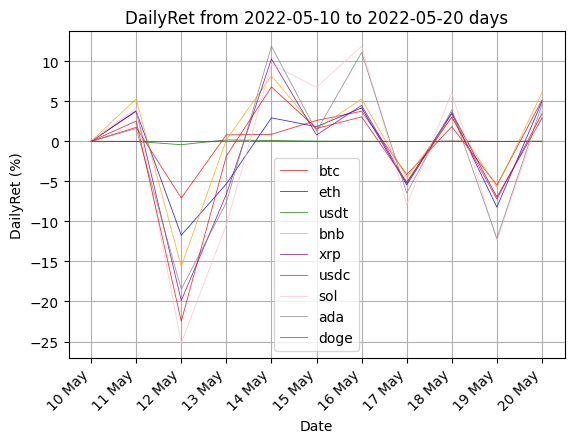

In [25]:
main_cryptos=topcryptos
#same start and end
#same feature
variation='DailyRet'
feature='ReferenceRate'
df_lunaeffect=gettimedelta(df_final,start,end)
df_lunaeffect=getdailyreturns(main_cryptos,df_lunaeffect,feature,variation)
plotthedatas(df_lunaeffect,variation,start,end,main_cryptos)


The Binance/FTX scandal in late 2022 was one of the most significant events in the cryptocurrency world, leading to the collapse of FTX, one of the largest cryptocurrency exchanges, and severely damaging trust in the crypto market.

FTX was founded by Sam Bankman-Fried and quickly rose until it became the third largest cryptocurrency exchanges globally. In late 2022, concerns arose when a leaked document revealed that Alameda Research (a trading firm also founded by Sam Bankman-Fried and closely tied to FTX) had a balance sheet heavily reliant on FTT, FTX’s native token. This raised many questions about FTX’s financial stability.

The big problems surged when Binance’s CEO announced that Binance would sell its significant holdings of FTT tokens, citing recent revelations and concerns about risk management at FTX. This announcement led to a massive sell-off of FTT, causing the token’s price to plummet by over 80% in just a few days.

What's more, the rapid decline in FTT’s value spurred a liquidity crisis at FTX. Users rushed to withdraw their funds, but FTX was unable to fulfill the withdrawal requests, as its assets were tied up or insufficient to meet the demands.

Following this, FTX filed for bankruptcy on November 11, 2022

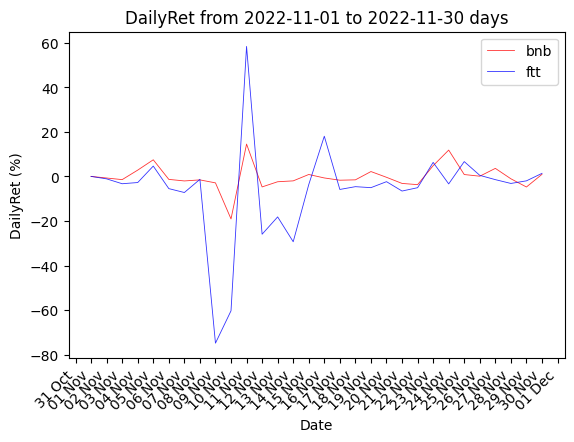

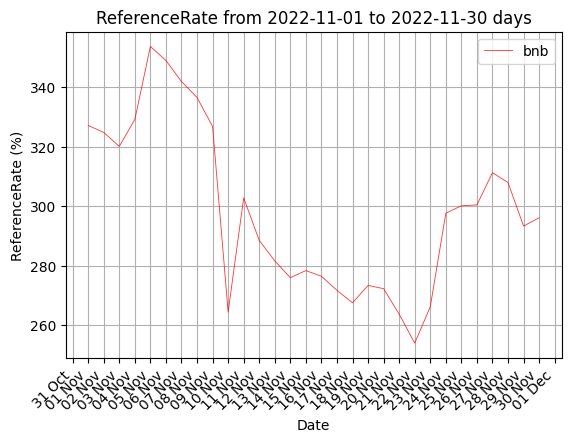

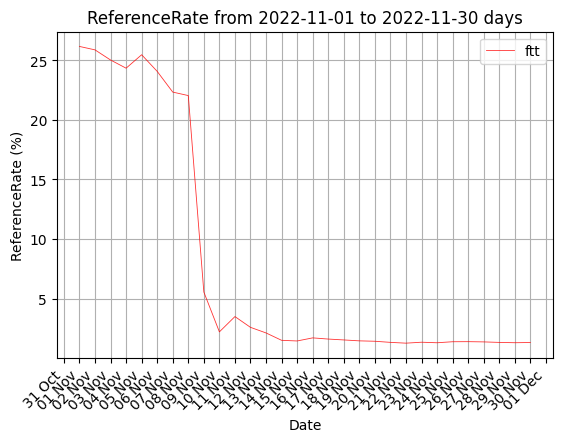

In [26]:
cryptos=['bnb','ftt']
start='2022-11-01'
end='2022-11-30'
df_binance=gettimedelta(df_final,start,end)
df_binance=df_binance[df_binance['Cryptocurrency'].isin(cryptos)]
df_binance=getdailyreturns(cryptos,df_binance,'ReferenceRate','DailyRet')
plotthedatas(df_binance,'DailyRet',start,end,cryptos)
plotthedatas(df_binance,'ReferenceRate',start,end,['bnb'])
plotthedatas(df_binance,'ReferenceRate',start,end,['ftt'])



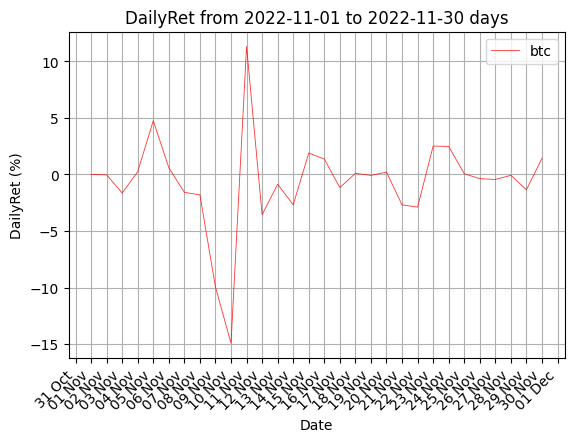

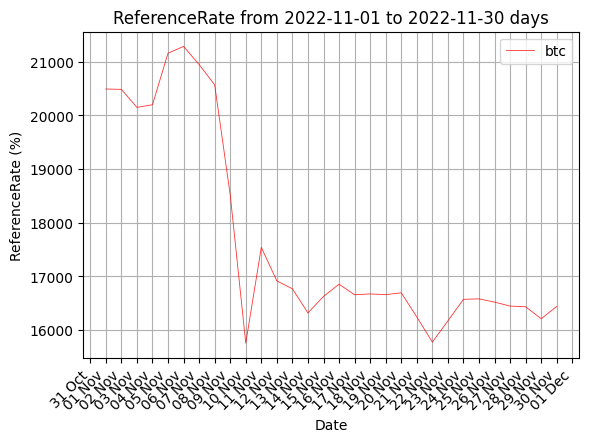

In [27]:
cryptos=['btc']
start='2022-11-01'
end='2022-11-30'
df_binance_btc=gettimedelta(df_final,start,end)
df_binance_btc=df_binance_btc[df_binance_btc['Cryptocurrency'].isin(cryptos)]
df_binance_btc=getdailyreturns(cryptos,df_binance_btc,'ReferenceRate','DailyRet')
plotthedatas(df_binance_btc,'DailyRet',start,end,cryptos)
plotthedatas(df_binance_btc,'ReferenceRate',start,end,['btc'])


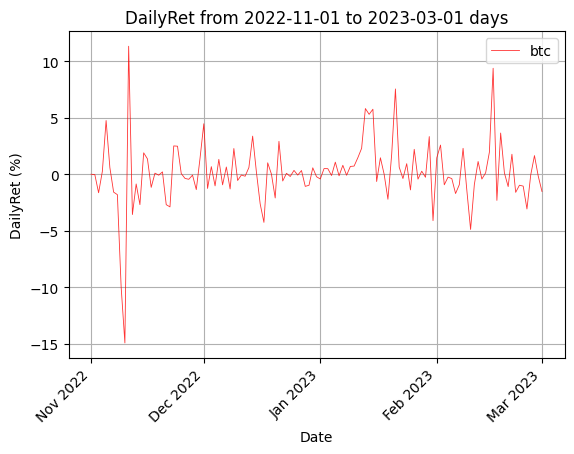

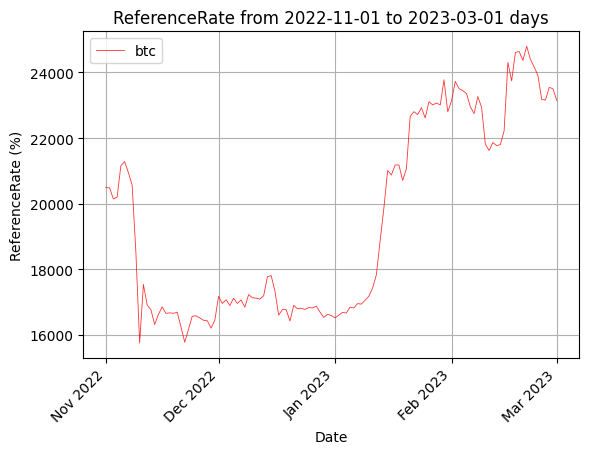

In [28]:
end='2023-03-01'
df_binance_btc2=gettimedelta(df_final,start,end)
df_binance_btc2=df_binance_btc2[df_binance_btc2['Cryptocurrency'].isin(cryptos)]
df_binance_btc2=getdailyreturns(cryptos,df_binance_btc2,'ReferenceRate','DailyRet')
plotthedatas(df_binance_btc2,'DailyRet',start,end,cryptos)
plotthedatas(df_binance_btc2,'ReferenceRate',start,end,['btc'])

BONUS 

ELON MUSK TWEETS 

(LOL)

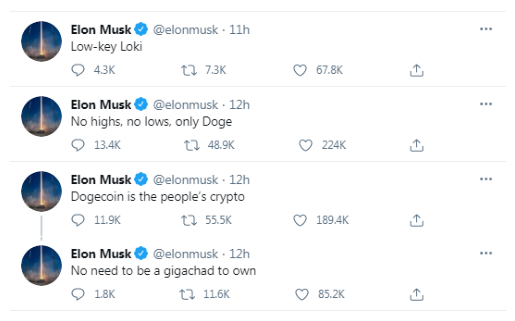

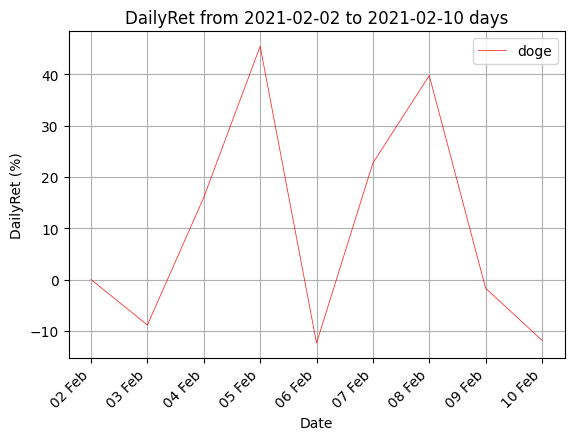

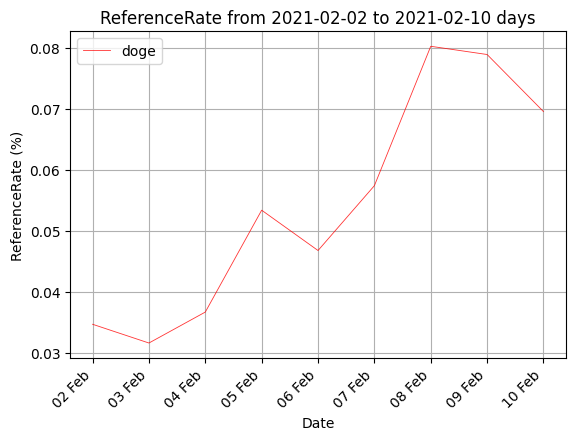

In [29]:
start='2021-02-02'
end='2021-02-10'
crypto=['doge']
df_doge_musk=gettimedelta(df_final,start,end)
df_doge_musk=getdailyreturns(crypto,df_doge_musk,'ReferenceRate','DailyRet')
##
from PIL import Image
import matplotlib.pyplot as plt

# Open the WEBP image file
image = Image.open('/Users/baudotedua/Dropbox/Mac/Desktop/PYTHON/QUANT/QuantInterviewProject/c44Il41c-elon-musk.webp')

# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off axis labels for cleaner display
plt.show()
##
plotthedatas(df_doge_musk,'DailyRet',start,end,crypto)
plotthedatas(df_doge_musk,'ReferenceRate',start,end,crypto)



After all, we're still talking about a meme-coin

MONTECARLO SIMULATION

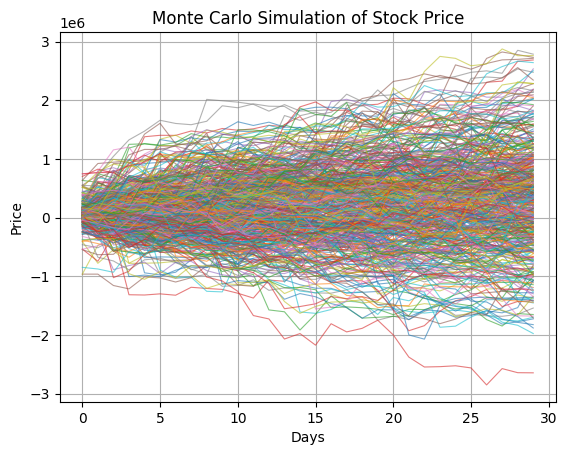

In [30]:
#we need the daily returns of a given list of stocks 
#we need to calculate the mean for each stocks (in a vector) and the covariance matrix 

#one variable 
crypto=['btc']
end='2024-10-04' 
start='2022-06-04'  
#mi serve la media dei ritorni e la deviazione standard
df_btc=df_final.loc[df_final['Cryptocurrency']=='btc']
df_montecarlo=gettimedelta(df_btc,start,end)
df_dailyret=getdailyreturns(crypto,df_montecarlo,'ReferenceRate','DailyRet')
mu=df_dailyret.DailyRet.mean()
sigma=df_dailyret.DailyRet.std()
#days for future forecasts 
days=30
numSim=500

sim_res=np.zeros((days,numSim))

last_price=df_dailyret.iloc[-1].ReferenceRate

for i in range(numSim):
   
    cum_ret=np.random.choice(df_dailyret.DailyRet, size=days , replace=True).cumsum()

    
    # Calculate the price series by taking the cumulative product of the returns
    #price_series = last_price * np.cumprod(1 + daily_returns)
    sim_res[: , i] = last_price * (1 + cum_ret)


# Plot the results
# plt.figure(figsize=(10, 6))
plt.plot(sim_res, alpha=0.6,linewidth=0.8)
plt.title('Monte Carlo Simulation of Stock Price')
plt.xlabel('Days')
plt.ylabel('Price')

plt.grid(True)
plt.show()






In [31]:
#multivariate index (crypto portfolio)
cryptos=['btc','eth','doge','bnb']
end='2024-10-04' 
start='2022-06-04'  
df_cleaned=df_final[df_final['Cryptocurrency'].isin(cryptos)]
df_cleaned=gettimedelta(df_cleaned,start,end)
df_cleaned=getdailyreturns(cryptos,df_cleaned,'ReferenceRate','DailyRet')
numdays=df_cleaned[df_cleaned['Cryptocurrency']=='btc'].shape[0]

matrix_mean=np.zeros((numdays,len(cryptos)))
for i in range(len(cryptos)):
    meanvect=df_cleaned[df_cleaned['Cryptocurrency']==cryptos[i]].DailyRet
    matrix_mean[:,i]=meanvect

mu=np.mean(matrix_mean,axis=0)

VAR=np.cov(matrix_mean,rowvar=False)

weights=np.ones(len(mu))*0.25



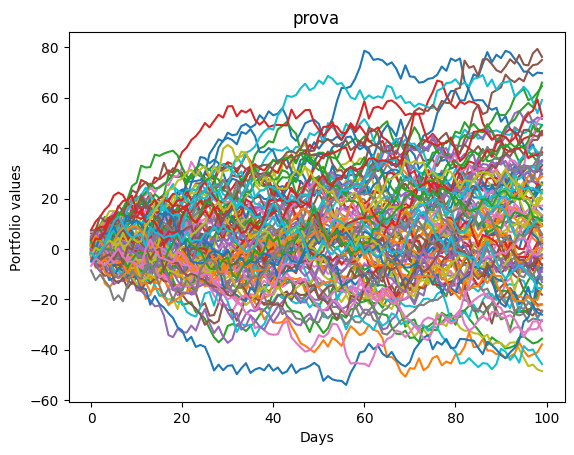

In [32]:
mc_sims=100
T=100

meanM=np.full(shape=(T , len(mu)),fill_value=mu)
meanM=meanM.T

portfolio_sims=np.full(shape=(T , mc_sims),fill_value=0.0)

initialPortfolio=10

for m in range (0,mc_sims):
    Z = np.random.normal(size=(T , len(mu)))
    L = np.linalg.cholesky(VAR)
    DailyReturns= meanM + np.inner(L,Z)
    portfolio_sims[:,m]=np.cumsum(np.inner(weights,DailyReturns.T))

plt.plot(portfolio_sims)
plt.ylabel('Portfolio values') 
plt.xlabel('Days')
plt.title('prova') 

plt.show()


